# Ancillary Fund Pool Redistribution — Layer 1 Model

**What this notebook does:** walks step-by-step through the redistribution model for the PAF/PuAF distribution pool — the pool, who is eligible today, the three allocation rules, incumbent dilution under reform, and the today-vs-reform slices for the four campaign target cohorts.

**Data dependencies** (produced by the R `targets` pipeline, snapshot 2026-07-21):
- `data/analytical/ancillary_funds_timeseries.csv`
- `data/analytical/dgr_gap_analysis.parquet`
- `data/analytical/reform_scenarios.csv` (used as a cross-check)

**Model in one sentence:** ancillary funds must give ~$1.5bn/yr to DGR-endorsed charities only; we assume a mechanical allocation rule (by revenue, by donations, or equal per charity), then widen the eligible base from current DGRs to all charities and see how the slices move.

> ⚠️ These are **access scenarios, not predicted flows** — recipient-level distribution data is never published by the ATO. Fixed-pool view: cohort gains come out of incumbents' share (Layer 1). Pie growth from increased giving is Layer 2, modelled separately.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Resolve the data folder whether the notebook runs from analysis/ or repo root
DATA = Path("../data/analytical")
if not DATA.exists():
    DATA = Path("data/analytical")
assert DATA.exists(), "Run from the repo root or analysis/ folder"

pd.options.display.float_format = "{:,.2f}".format

SUBTYPES = [
    "disaster_preparedness",
    "human_rights",
    "injury_prevention",
    "neighbourhood_house",
]

# ---- shared design system ---------------------------------------------------
C = {
    "paf": "#1b6ca8",        # PAF (dark blue)
    "puaf": "#7fb3d5",       # PuAF (light blue)
    "incumbent": "#25605f",  # current DGRs (teal)
    "new": "#e8702a",        # newly eligible (orange)
    "today": "#9aa5b1",      # 'today' reference (grey)
    "outside": "#d9d9d9",    # non-DGR (light grey)
    "pos": "#2e7d32",
    "neg": "#b3402a",
}
RULE_ORDER = ["donations", "revenue", "count"]
RULE_LABEL = {"donations": "Donations rule", "revenue": "Revenue rule", "count": "Count rule"}
RULE_COLOR = {"donations": "#1b6ca8", "revenue": "#25605f", "count": "#e8702a"}

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "legend.frameon": False,
    "font.size": 10,
})

def fmt_m(ax, axis="y", dec=0):
    """$m tick labels on the chosen axis."""
    getattr(ax, f"{axis}axis").set_major_formatter(
        mtick.StrMethodFormatter(f"${{x:,.{dec}f}}m")
    )

## Step 1 — The pool: what ancillary funds distribute

Ancillary funds (private = PAF, public = PuAF) are **Item 2 DGRs**: tax-advantaged giving vehicles whose distributions are legally restricted to **Item 1 DGRs**. The ATO publishes aggregate donations in, distributions out, and net assets per year (Taxation Statistics, charities Table 4).

In [36]:
anc = pd.read_csv(DATA / "ancillary_funds_timeseries.csv")

latest_fy = anc["income_year"].max()
latest = anc[anc["income_year"] == latest_fy]
POOL = latest["distributions_made"].sum()

summary = latest.set_index("fund_type")[
    ["n_funds", "donations_received", "distributions_made", "net_assets"]
].copy()
summary.loc["Total"] = summary.sum()
summary["payout_rate_%"] = 100 * summary["distributions_made"] / summary["net_assets"]

print(f"Pool ({latest_fy} PAF+PuAF distributions): ${POOL/1e6:,.0f}m")
summary

Pool (2023-24 PAF+PuAF distributions): $1,527m


,n_funds,donations_received,distributions_made,net_assets,payout_rate_%
fund_type,,,,,
PAF,2289,1116937761,914435664,13265693532,6.89
PuAF,1425,632761448,612830300,4266227180,14.36
Total,3714,1749699209,1527265964,17531920712,8.71


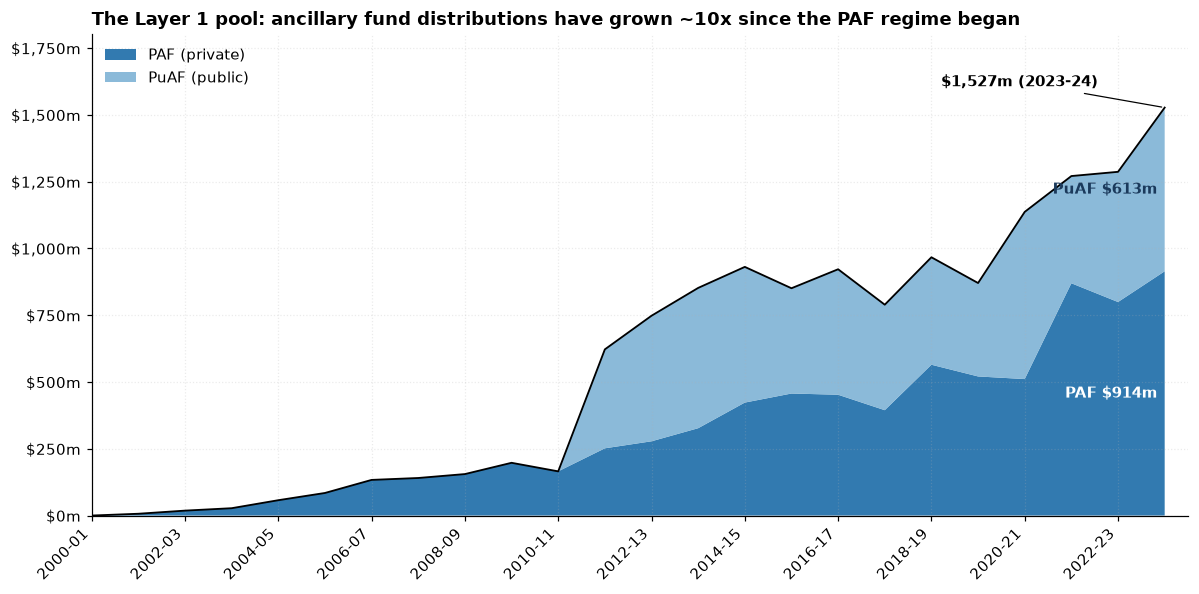

PAFs cluster near their 5% minimum payout; PuAFs pay well above their 4% minimum.


In [37]:
# Pool trend: distributions out by fund type
trend = anc.pivot_table(
    index="income_year", columns="fund_type",
    values="distributions_made", aggfunc="sum",
).fillna(0)[["PAF", "PuAF"]] / 1e6

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(trend))
ax.stackplot(
    x, trend["PAF"], trend["PuAF"],
    labels=["PAF (private)", "PuAF (public)"],
    colors=[C["paf"], C["puaf"]], alpha=0.9,
)
tot = trend.sum(axis=1)
ax.plot(x, tot, color="black", lw=1.2)

# annotate the latest year (the pool used in this model)
ax.annotate(
    f"${tot.iloc[-1]:,.0f}m ({trend.index[-1]})",
    xy=(x[-1], tot.iloc[-1]), xytext=(-95, 14), textcoords="offset points",
    fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
)
# annotate split of latest year inside the bands
ax.text(x[-1] - 0.15, trend["PAF"].iloc[-1] / 2, f"PAF ${trend['PAF'].iloc[-1]:,.0f}m",
        ha="right", va="center", color="white", fontweight="bold")
ax.text(x[-1] - 0.15, trend["PAF"].iloc[-1] + trend["PuAF"].iloc[-1] / 2,
        f"PuAF ${trend['PuAF'].iloc[-1]:,.0f}m", ha="right", va="center",
        color="#1b3a5c", fontweight="bold")

ax.set_xticks(x[::2], trend.index[::2], rotation=45, ha="right")
ax.set_xlim(0, len(trend) - 0.5)
ax.set_ylim(0, tot.max() * 1.18)
ax.margins(x=0)
fmt_m(ax)
ax.set_title("The Layer 1 pool: ancillary fund distributions have grown ~10x since the PAF regime began")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("PAFs cluster near their 5% minimum payout; PuAFs pay well above their 4% minimum.")

## Step 2 — Who is inside the fence today?

The eligible base is every charity with financials in the latest AIS year (ancillary funds themselves excluded — a PAF cannot fund another PAF). Today only DGR-endorsed charities can receive the pool.

In [38]:
gap = pd.read_parquet(DATA / "dgr_gap_analysis.parquet")

latest_yr = gap["ais_year"].max()
base = gap[gap["ais_year"] == latest_yr].copy()
base["revenue"] = base["total_gross_income"].fillna(0).clip(lower=0)
base["donations"] = base["donations_and_bequests"].fillna(0).clip(lower=0)

def weights(df):
    """Total weight of a charity set under each allocation rule."""
    return pd.Series(
        {"revenue": df["revenue"].sum(), "donations": df["donations"].sum(), "count": len(df)}
    )

dgr_base = base[base["has_dgr"]]
w_today = weights(dgr_base)      # denominator today
w_reform = weights(base)         # denominator under (full) reform

fence = pd.DataFrame({
    "DGR (inside fence)": weights(dgr_base),
    "non-DGR (outside)": weights(base[~base["has_dgr"]]),
})
fence["DGR share %"] = 100 * fence["DGR (inside fence)"] / fence.sum(axis=1)
print(f"Latest AIS year: {latest_yr} | eligible base: {len(base):,} charities")
fence

Latest AIS year: 2024 | eligible base: 49,914 charities


,DGR (inside fence),non-DGR (outside),DGR share %
revenue,"151,840,198,100.00","93,466,686,179.00",61.90
donations,"9,172,295,776.00","2,596,522,214.00",77.94
count,"20,107.00","29,807.00",40.28


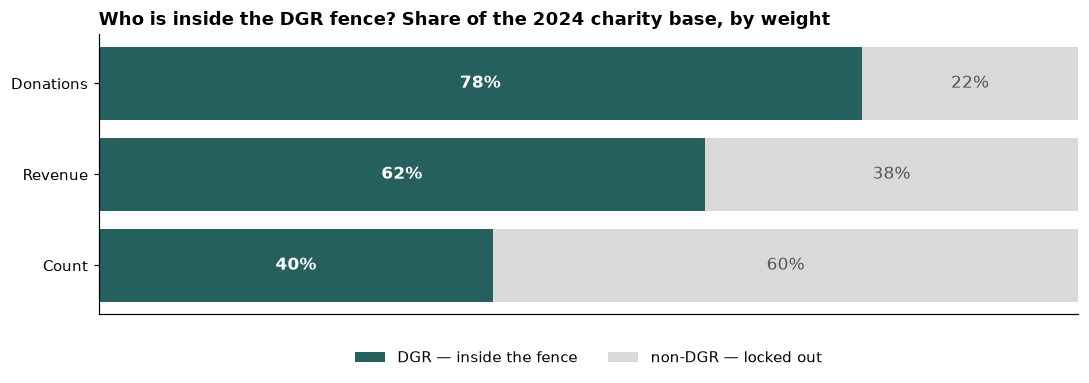

DGR charities are only ~40% by count but ~62% of revenue and ~78% of donations:
endorsement is concentrated among larger, donation-attracting charities.


In [39]:
# The fence as a 100%-stacked bar: inside vs outside, under each weighting
share = fence["DGR share %"].reindex(RULE_ORDER)

fig, ax = plt.subplots(figsize=(10, 3.6))
y = np.arange(len(share))
ax.barh(y, share, color=C["incumbent"], label="DGR — inside the fence")
ax.barh(y, 100 - share, left=share, color=C["outside"], label="non-DGR — locked out")

for i, v in enumerate(share):
    ax.text(v / 2, i, f"{v:.0f}%", va="center", ha="center",
            color="white", fontweight="bold", fontsize=11)
    ax.text(v + (100 - v) / 2, i, f"{100 - v:.0f}%", va="center", ha="center",
            color="#555", fontsize=11)

ax.set_yticks(y, [RULE_LABEL[r].replace(" rule", "") for r in share.index])
ax.set_xlim(0, 100)
ax.set_xticks([])
ax.grid(False)
ax.set_title(f"Who is inside the DGR fence? Share of the {latest_yr} charity base, by weight")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncols=2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(
    "DGR charities are only ~40% by count but ~62% of revenue and ~78% of donations:\n"
    "endorsement is concentrated among larger, donation-attracting charities."
)

## Step 3 — The three allocation rules

We cannot observe who actually receives the pool, so each scenario assumes a mechanical sharing rule. For eligible set $E$, charity weights $w_i$, and pool $P$, a cohort $C \subseteq E$ receives:

$$\text{dollars}(C) = P \times \frac{\sum_{i \in C} w_i}{\sum_{j \in E} w_j}, \qquad w_i \in \{r_i \text{ (revenue)},\; d_i \text{ (donations)},\; 1 \text{ (count)}\}$$

- **revenue** — proportional to organisational scale
- **donations** — proportional to demonstrated fundability
- **count** — equal scoop per charity

The two scenarios differ only in $E$: **today** = current DGRs; **reform** = all charities. Same rule, bigger base.

## Step 4 — Incumbent dilution: how much of the pool moves?

Because the pool is fixed, widening the base mechanically dilutes incumbents. The share current DGRs keep is simply (today's total weight) ÷ (reform total weight).

In [40]:
dilution = pd.DataFrame({
    "keep_share_%": 100 * w_today / w_reform,
    "stays_$m": POOL * (w_today / w_reform) / 1e6,
    "moves_$m": POOL * (1 - w_today / w_reform) / 1e6,
}).round(1)
dilution.index.name = "rule"
dilution

,keep_share_%,stays_$m,moves_$m
rule,,,
revenue,61.90,945.30,581.90
donations,77.90,"1,190.30",337.00
count,40.30,615.20,912.00


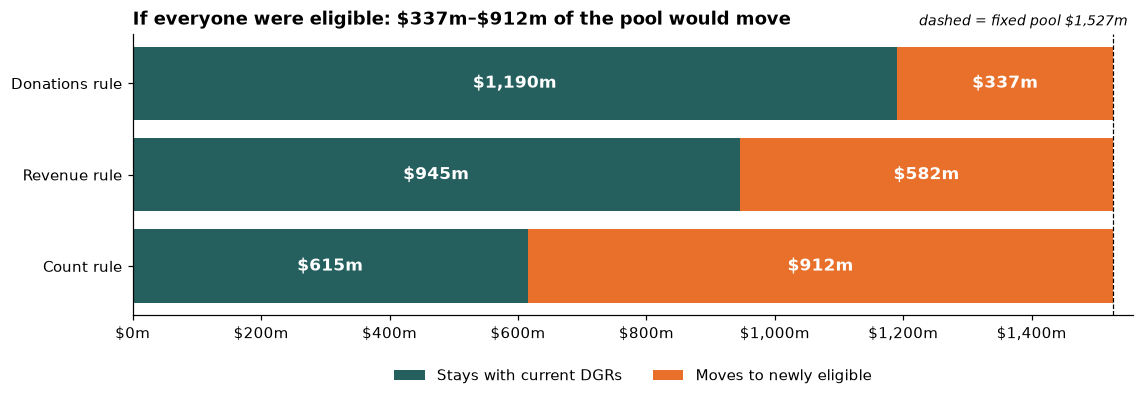

In [41]:
# Dilution: how the fixed pool splits once the fence comes down
d = dilution.reindex(RULE_ORDER)

fig, ax = plt.subplots(figsize=(10.5, 3.8))
y = np.arange(len(d))
ax.barh(y, d["stays_$m"], color=C["incumbent"], label="Stays with current DGRs")
ax.barh(y, d["moves_$m"], left=d["stays_$m"], color=C["new"], label="Moves to newly eligible")

for i, (s, m) in enumerate(zip(d["stays_$m"], d["moves_$m"])):
    ax.text(s / 2, i, f"${s:,.0f}m", va="center", ha="center",
            color="white", fontweight="bold", fontsize=11)
    ax.text(s + m / 2, i, f"${m:,.0f}m", va="center", ha="center",
            color="white", fontweight="bold", fontsize=11)

ax.axvline(POOL / 1e6, color="black", lw=0.8, ls="--")
ax.text(0.995, 1.03, f"dashed = fixed pool ${POOL/1e6:,.0f}m",
        transform=ax.transAxes, ha="right", fontsize=9, style="italic")

ax.set_yticks(y, [RULE_LABEL[r] for r in d.index])
ax.set_xlim(0, POOL / 1e6 * 1.02)
fmt_m(ax, "x")
ax.grid(False)
# NB: escaped \$ so matplotlib doesn't treat the pair as mathtext
ax.set_title("If everyone were eligible: \\$337m\u2013\\$912m of the pool would move")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Step 5 — Cohort slices: today vs reform

For each campaign cohort we compute its slice of the pool under each rule:

- **today** — only its DGR members share in the pool (denominator = DGR base)
- **reform** — all members share (denominator = full base), split into the existing-DGR part and the **newly-eligible** part

Only the newly-eligible part is a *reform benefit*; cohort members already holding DGR ("leakage") gain nothing new and are in fact diluted.

In [42]:
rows = []
for st in SUBTYPES:
    members = base[base["target_subtype"].str.contains(st, na=False)]
    dgr_members = members[members["has_dgr"]]
    newly_eligible = members[~members["has_dgr"]]
    w_dgr_m, w_ne = weights(dgr_members), weights(newly_eligible)
    for rule in ["revenue", "donations", "count"]:
        rows.append({
            "subtype": st,
            "rule": rule,
            "n_cohort": len(members),
            "n_newly_eligible": len(newly_eligible),
            "pct_already_dgr": round(100 * len(dgr_members) / len(members), 1),
            "today_$m": POOL * w_dgr_m[rule] / w_today[rule] / 1e6,
            "reform_$m": POOL * (w_dgr_m[rule] + w_ne[rule]) / w_reform[rule] / 1e6,
            "newly_eligible_$m": POOL * w_ne[rule] / w_reform[rule] / 1e6,
        })

res = pd.DataFrame(rows)
res["net_change_$m"] = res["reform_$m"] - res["today_$m"]
res.round(1)

,subtype,rule,n_cohort,n_newly_eligible,pct_already_dgr,today_$m,reform_$m,newly_eligible_$m,net_change_$m
0,disaster_preparedness,revenue,339,126,62.80,23.80,15.60,0.90,-8.20
1,disaster_preparedness,donations,339,126,62.80,90.30,74.10,3.80,-16.20
2,disaster_preparedness,count,339,126,62.80,16.20,10.40,3.90,-5.80
3,human_rights,revenue,661,241,63.50,33.60,22.30,1.50,-11.30
4,human_rights,donations,661,241,63.50,89.60,75.30,5.40,-14.40
5,human_rights,count,661,241,63.50,31.90,20.20,7.40,-11.70
6,injury_prevention,revenue,229,74,67.70,5.60,4.30,0.90,-1.20
7,injury_prevention,donations,229,74,67.70,8.20,6.60,0.20,-1.60
8,injury_prevention,count,229,74,67.70,11.80,7.00,2.30,-4.80
9,neighbourhood_house,revenue,284,209,26.40,1.10,1.30,0.60,0.20


In [43]:
# Cross-check the newly-eligible dollars against the pipeline's reform_scenarios output
scen = pd.read_csv(DATA / "reform_scenarios.csv")
scen["rule"] = scen["basis"].str.replace("_share", "", regex=False)
check = res.merge(
    scen[["subtype", "rule", "annual_dollars"]], on=["subtype", "rule"]
)
check["pipeline_$m"] = check["annual_dollars"] / 1e6
check["diff_$"] = (check["newly_eligible_$m"] - check["pipeline_$m"]).abs() * 1e6
ok = (check["diff_$"] < 1).all()
print("Cross-check vs reform_scenarios.csv:", "PASS ✔" if ok else "MISMATCH ✖")
check[["subtype", "rule", "newly_eligible_$m", "pipeline_$m"]].round(2)

Cross-check vs reform_scenarios.csv: PASS ✔


,subtype,rule,newly_eligible_$m,pipeline_$m
0,disaster_preparedness,revenue,0.87,0.87
1,disaster_preparedness,donations,3.76,3.76
2,disaster_preparedness,count,3.86,3.86
3,human_rights,revenue,1.52,1.52
4,human_rights,donations,5.40,5.40
5,human_rights,count,7.37,7.37
6,injury_prevention,revenue,0.88,0.88
7,injury_prevention,donations,0.18,0.18
8,injury_prevention,count,2.26,2.26
9,neighbourhood_house,revenue,0.61,0.61


### Reality check — can the "today" numbers be squared with actual receipts?

The ATO never publishes who receives ancillary distributions, so the "today" bars are **modelled shares, not observed flows**. But we can bound them with real data: when a PAF grants to a charity, the recipient reports it inside **donations and bequests** in its AIS. So a cohort's *actual reported donations* is a hard ceiling on what it could possibly have received from ancillary funds.

Two useful facts fall out:

1. The pool is **16.7% of all donations reported by DGR charities** ($1,527m of $9,172m). Under the *donations rule* every cohort's modelled receipt is exactly 16.7% of its actual donations — it can never breach the ceiling. The $90m for disaster preparedness looks large, but that cohort actually reported ~$542m in donations (it contains the big disaster charities — Red Cross-scale organisations), so $90m is a plausible one-sixth of it.
2. The *revenue* and *count* rules ignore what charities actually attract, so they **can** breach the ceiling — the check below flags any cohort×rule where modelled ancillary receipts exceed 100% of actual donations, which tells you that rule is implausible for that cohort.

In [44]:
# Plausibility check: modelled 'today' ancillary receipts vs actual reported donations
all_dgr_don = dgr_base["donations"].sum()
print(f"Pool = ${POOL/1e6:,.0f}m | donations reported by all DGR charities = "
      f"${all_dgr_don/1e6:,.0f}m | pool/donations = {POOL/all_dgr_don:.1%}\n")

rc = []
for st in SUBTYPES:
    m_dgr = base[base["target_subtype"].str.contains(st, na=False) & base["has_dgr"]]
    actual_don = m_dgr["donations"].sum() / 1e6
    for r in RULE_ORDER:
        modelled = res.loc[(res["subtype"] == st) & (res["rule"] == r), "today_$m"].iloc[0]
        rc.append({
            "subtype": st, "rule": r,
            "modelled_today_$m": modelled,
            "actual_donations_$m": actual_don,
            "modelled_as_%_of_actual": 100 * modelled / actual_don,
        })

rc = pd.DataFrame(rc)
rc["plausible"] = np.where(rc["modelled_as_%_of_actual"] <= 100, "yes", "NO — exceeds ceiling")
rc.round(1)

Pool = $1,527m | donations reported by all DGR charities = $9,172m | pool/donations = 16.7%



,subtype,rule,modelled_today_$m,actual_donations_$m,modelled_as_%_of_actual,plausible
0,disaster_preparedness,donations,90.30,542.10,16.70,yes
1,disaster_preparedness,revenue,23.80,542.10,4.40,yes
2,disaster_preparedness,count,16.20,542.10,3.00,yes
3,human_rights,donations,89.60,538.30,16.70,yes
4,human_rights,revenue,33.60,538.30,6.20,yes
5,human_rights,count,31.90,538.30,5.90,yes
6,injury_prevention,donations,8.20,49.20,16.70,yes
7,injury_prevention,revenue,5.60,49.20,11.30,yes
8,injury_prevention,count,11.80,49.20,23.90,yes
9,neighbourhood_house,donations,0.40,2.50,16.70,yes


In [ ]:
# The anchor chart: donations rule pins every cohort at 16.7%; revenue and count
# scatter around it depending on whether the cohort is donation-rich or -poor
# relative to its scale. Above the anchor = the rule flatters the cohort.
ANCHOR = 100 * POOL / all_dgr_don   # 16.7%

fig, ax = plt.subplots(figsize=(11, 5.5))
ylab = [s.replace("_", " ") for s in SUBTYPES]
yy = np.arange(len(SUBTYPES))

for r in RULE_ORDER:
    d = rc[rc["rule"] == r].set_index("subtype").reindex(SUBTYPES)
    vals = d["modelled_as_%_of_actual"]
    ax.scatter(vals, yy, s=110, color=RULE_COLOR[r], zorder=3, label=RULE_LABEL[r])
    if r != "donations":
        # connector back to the anchor shows the distortion each rule introduces
        for yi, v in zip(yy, vals):
            ax.plot([ANCHOR, v], [yi, yi], color=RULE_COLOR[r], lw=1.2,
                    alpha=0.45, zorder=2)
        for yi, v in zip(yy, vals):
            ax.text(v, yi - 0.22, f"{v:,.0f}%", ha="center", fontsize=8,
                    color=RULE_COLOR[r])

ax.axvline(ANCHOR, color=RULE_COLOR["donations"], lw=1.4, ls="--", zorder=1)
ax.text(ANCHOR, len(SUBTYPES) - 0.35, f" anchor {ANCHOR:.1f}%\n (pool ÷ all DGR donations)",
        fontsize=8.5, color=RULE_COLOR["donations"], va="top")
ax.axvline(100, color=C["neg"], lw=1.2, zorder=1)
ax.text(100, -0.45, " 100% = cohort's entire reported donations",
        fontsize=8.5, color=C["neg"], va="bottom")

ax.set_xscale("log")
ax.set_xticks([2, 5, 10, 16.7, 30, 50, 100, 250])
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}%"))
ax.set_yticks(yy, ylab)
ax.invert_yaxis()
ax.set_xlabel("modelled 'today' ancillary receipts as % of the cohort's actual reported donations (log scale)")
ax.set_title("The donations rule anchors every cohort at 16.7%; revenue and count drift with cohort make-up")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(
    "Left of the anchor: the cohort attracts more donations than its scale suggests,\n"
    "so scale-based rules under-allocate it. Right: donation-poor for its size, so\n"
    "revenue/count flatter it — neighbourhood houses under count even beat what the\n"
    "whole cohort actually raises (230%), which is why that cell is flagged implausible."
)

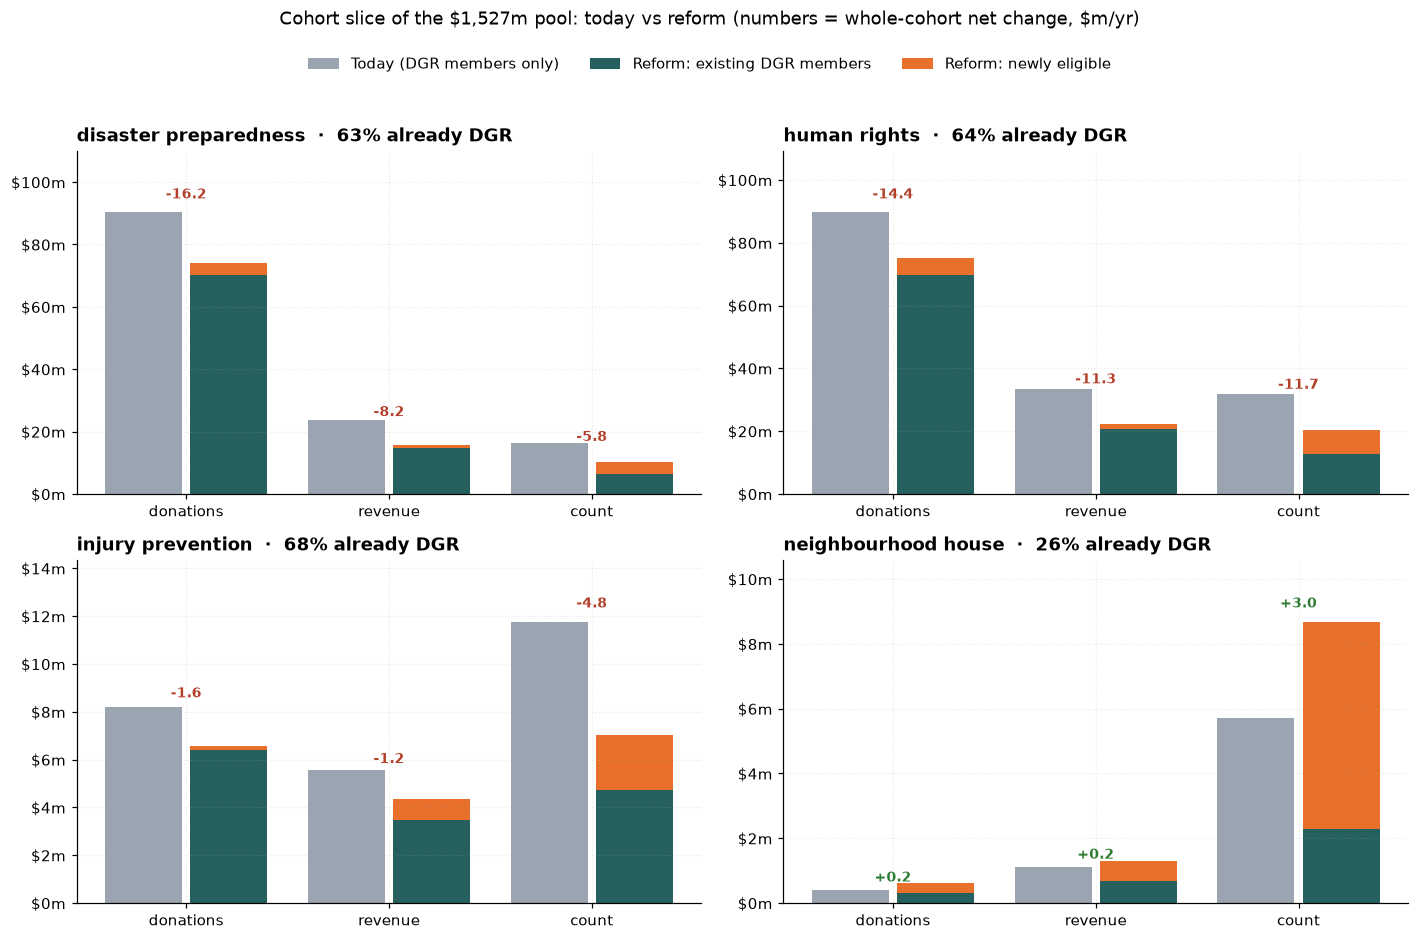

In [45]:
# Today vs reform per cohort: reform bar stacked into existing-DGR + newly-eligible parts
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for ax, st in zip(axes.flat, SUBTYPES):
    d = res[res["subtype"] == st].set_index("rule").reindex(RULE_ORDER)
    x = np.arange(len(d))
    existing = d["reform_$m"] - d["newly_eligible_$m"]

    ax.bar(x - 0.21, d["today_$m"], width=0.38, color=C["today"], label="Today (DGR members only)")
    ax.bar(x + 0.21, existing, width=0.38, color=C["incumbent"], label="Reform: existing DGR members")
    ax.bar(x + 0.21, d["newly_eligible_$m"], width=0.38, bottom=existing,
           color=C["new"], label="Reform: newly eligible")

    # net change callout above each pair
    top = np.maximum(d["today_$m"], d["reform_$m"])
    for xi, (t, nc) in zip(x, zip(top, d["net_change_$m"])):
        ax.text(xi, t * 1.05, f"{nc:+.1f}", ha="center", fontsize=9, fontweight="bold",
                color=C["pos"] if nc >= 0 else C["neg"])

    ax.set_xticks(x, [r.replace(" rule", "") for r in d.index])
    ax.set_ylim(0, top.max() * 1.22)
    ax.set_title(f"{st.replace('_', ' ')}  ·  {d['pct_already_dgr'].iloc[0]:.0f}% already DGR")
    fmt_m(ax)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965), ncols=3)
fig.suptitle(
    f"Cohort slice of the \\${POOL/1e6:,.0f}m pool: today vs reform "
    "(numbers = whole-cohort net change, \\$m/yr)",
    y=1.0,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [46]:
# Headline: newly-eligible dollars (the reform benefit), min–max range per cohort
headline = (
    res.pivot_table(index="subtype", columns="rule", values="newly_eligible_$m")
    .assign(range=lambda d: d.min(axis=1).round(1).astype(str) + " – " + d.max(axis=1).round(1).astype(str))
)
headline.columns.name = None
total = res.groupby("rule")["newly_eligible_$m"].sum()
print(f"All four cohorts combined: ${total.min():.1f}m – ${total.max():.1f}m per year "
      f"(min rule: {total.idxmin()}, max rule: {total.idxmax()})")
headline.round(1)

All four cohorts combined: $3.9m – $19.9m per year (min rule: revenue, max rule: count)


,count,donations,revenue,range
subtype,,,,
disaster_preparedness,3.90,3.80,0.90,0.9 – 3.9
human_rights,7.40,5.40,1.50,1.5 – 7.4
injury_prevention,2.30,0.20,0.90,0.2 – 2.3
neighbourhood_house,6.40,0.30,0.60,0.3 – 6.4


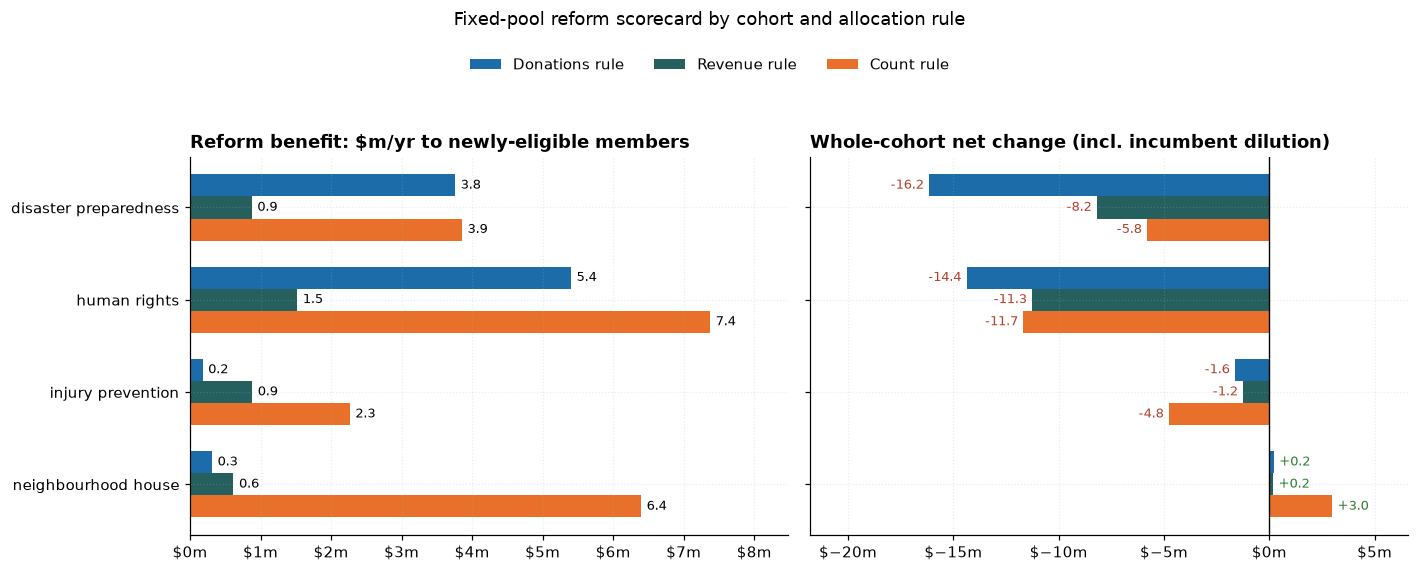

neighbourhood_house is the only cohort in the black under every rule — its low DGR coverage (26%) means little dilution to offset the new access.


In [47]:
# Summary: the two numbers that matter, side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ylabels = [s.replace("_", " ") for s in SUBTYPES]
y = np.arange(len(SUBTYPES))
h = 0.24

for k, rule in enumerate(RULE_ORDER):
    d = res[res["rule"] == rule].set_index("subtype").reindex(SUBTYPES)
    off = (k - 1) * h
    ax1.barh(y + off, d["newly_eligible_$m"], height=h, color=RULE_COLOR[rule],
             label=RULE_LABEL[rule])
    ax2.barh(y + off, d["net_change_$m"], height=h, color=RULE_COLOR[rule])
    for yi, v in zip(y + off, d["newly_eligible_$m"]):
        ax1.text(v + 0.08, yi, f"{v:.1f}", va="center", fontsize=8.5)
    for yi, v in zip(y + off, d["net_change_$m"]):
        ax2.text(v + (0.25 if v >= 0 else -0.25), yi, f"{v:+.1f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8.5,
                 color=C["pos"] if v >= 0 else C["neg"])

ax1.set_yticks(y, ylabels)
ax1.invert_yaxis()
ax1.set_title("Reform benefit: \\$m/yr to newly-eligible members")
fmt_m(ax1, "x")
ax1.set_xlim(0, res["newly_eligible_$m"].max() * 1.15)

ax2.axvline(0, color="black", lw=0.9)
ax2.set_title("Whole-cohort net change (incl. incumbent dilution)")
fmt_m(ax2, "x")
ax2.set_xlim(res["net_change_$m"].min() * 1.35, res["net_change_$m"].max() * 2.2)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97), ncols=3)
fig.suptitle("Fixed-pool reform scorecard by cohort and allocation rule", y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

print("neighbourhood_house is the only cohort in the black under every rule — "
      "its low DGR coverage (26%) means little dilution to offset the new access.")

## Step 6 — One pool, three futures: the hero visual

The whole model in one static picture. The **fixed $1,527m pool** flows into three reform scenarios:

1. **Full DGR** — every registered charity becomes eligible (49,914 orgs).
2. **Selective DGR** — DGR is re-tested for *everyone*: charities pass unless flagged for excluded purposes; incumbents who fail **lose** their endorsement, and their share of the pool is reallocated.
3. **Selective + grandfathered** — same selective test for newcomers, but **no current DGR loses** endorsement.

> ⚠️ **Illustrative proxy** for "selective": eligible unless flagged `advancing_religion` or `early_childhood` on the ACNC register (echoing the Productivity Commission's proposed carve-outs; `advancing_education` is deliberately *not* used because it would sweep in universities, whereas the PC excluded only school building funds / childcare). When `analysis/reform_eligibility_flags.csv` lands (one `abn` column), it automatically replaces this proxy.

Dollar figures are shown as **min–max across the three allocation rules** (donations / revenue / count).

In [48]:
# Scenario engine: eligible sets -> pool split (min-max across allocation rules)
FLAGS_FILE = Path("reform_eligibility_flags.csv")

# Purpose flags from charity_master (proxy for the selective test)
master = pd.read_parquet(DATA / "charity_master.parquet",
                         columns=["abn", "advancing_religion", "early_childhood"])
b = base.merge(master, on="abn", how="left")

def as_flag(s):
    """ACNC register flags arrive as 'Y'/blank strings (or booleans)."""
    return s.astype(str).str.strip().str.upper().isin(["Y", "YES", "TRUE", "1"])

excluded_purpose = as_flag(b["advancing_religion"]) | as_flag(b["early_childhood"])

if FLAGS_FILE.exists():
    flagged = set(pd.read_csv(FLAGS_FILE)["abn"].astype(str))
    passes_test = b["abn"].astype(str).isin(flagged)
    print(f"Using eligibility flags file ({len(flagged):,} ABNs).")
else:
    passes_test = ~excluded_purpose
    print("Using illustrative proxy: eligible unless advancing_religion or early_childhood.")

is_dgr = b["has_dgr"]

# Eligibility masks per scenario
scenarios = {
    "full": pd.Series(True, index=b.index),   # everyone
    "selective": passes_test,                 # everyone re-tested (incumbents can lose)
    "grandfathered": is_dgr | passes_test,    # incumbents keep DGR regardless
}

def scenario_stats(mask):
    """Pool split per rule ($m) plus headcounts for one eligibility mask."""
    elig = b[mask]
    w_elig = weights(elig)
    split = pd.DataFrame({
        r: {
            "stays": POOL * weights(elig[elig["has_dgr"]])[r] / w_elig[r] / 1e6,
            "moves": POOL * weights(elig[~elig["has_dgr"]])[r] / w_elig[r] / 1e6,
        }
        for r in RULE_ORDER
    }).T
    # today-share of pool held by incumbents who would LOSE endorsement
    lose_share = [
        POOL * weights(b[~mask & is_dgr])[r] / w_today[r] / 1e6 for r in RULE_ORDER
    ]
    return {
        "split": split,
        "n_eligible": int(mask.sum()),
        "n_new": int((mask & ~is_dgr).sum()),
        "n_lose": int((~mask & is_dgr).sum()),
        "lost_range": (min(lose_share), max(lose_share)),
    }

S = {k: scenario_stats(m) for k, m in scenarios.items()}

for k, s in S.items():
    sp = s["split"]
    print(f"\n{k}: eligible {s['n_eligible']:,} | newcomers {s['n_new']:,} | "
          f"incumbents losing DGR {s['n_lose']:,}")
    print(f"  moves to newcomers: ${sp['moves'].min():,.0f}m – ${sp['moves'].max():,.0f}m"
          f" | stays: ${sp['stays'].min():,.0f}m – ${sp['stays'].max():,.0f}m")
    if s["n_lose"]:
        print(f"  de-endorsed incumbents currently hold ${s['lost_range'][0]:,.0f}m – "
              f"${s['lost_range'][1]:,.0f}m of today's pool")

# sanity: every rule's split must sum to the pool
for k, s in S.items():
    assert np.allclose(s["split"].sum(axis=1), POOL / 1e6), k
assert (S["grandfathered"]["split"]["stays"] >= S["selective"]["split"]["stays"]).all()
assert np.allclose(sorted(S["full"]["split"]["moves"].round(0)), [337, 582, 912])
print("\nSanity checks passed: splits sum to the pool; matches Step 4 dilution table.")

Using illustrative proxy: eligible unless advancing_religion or early_childhood.

full: eligible 49,914 | newcomers 29,807 | incumbents losing DGR 0
  moves to newcomers: $337m – $912m | stays: $615m – $1,190m

selective: eligible 24,446 | newcomers 11,591 | incumbents losing DGR 7,252
  moves to newcomers: $181m – $724m | stays: $803m – $1,347m
  de-endorsed incumbents currently hold $551m – $715m of today's pool

grandfathered: eligible 31,698 | newcomers 11,591 | incumbents losing DGR 0
  moves to newcomers: $102m – $558m | stays: $969m – $1,426m

Sanity checks passed: splits sum to the pool; matches Step 4 dilution table.


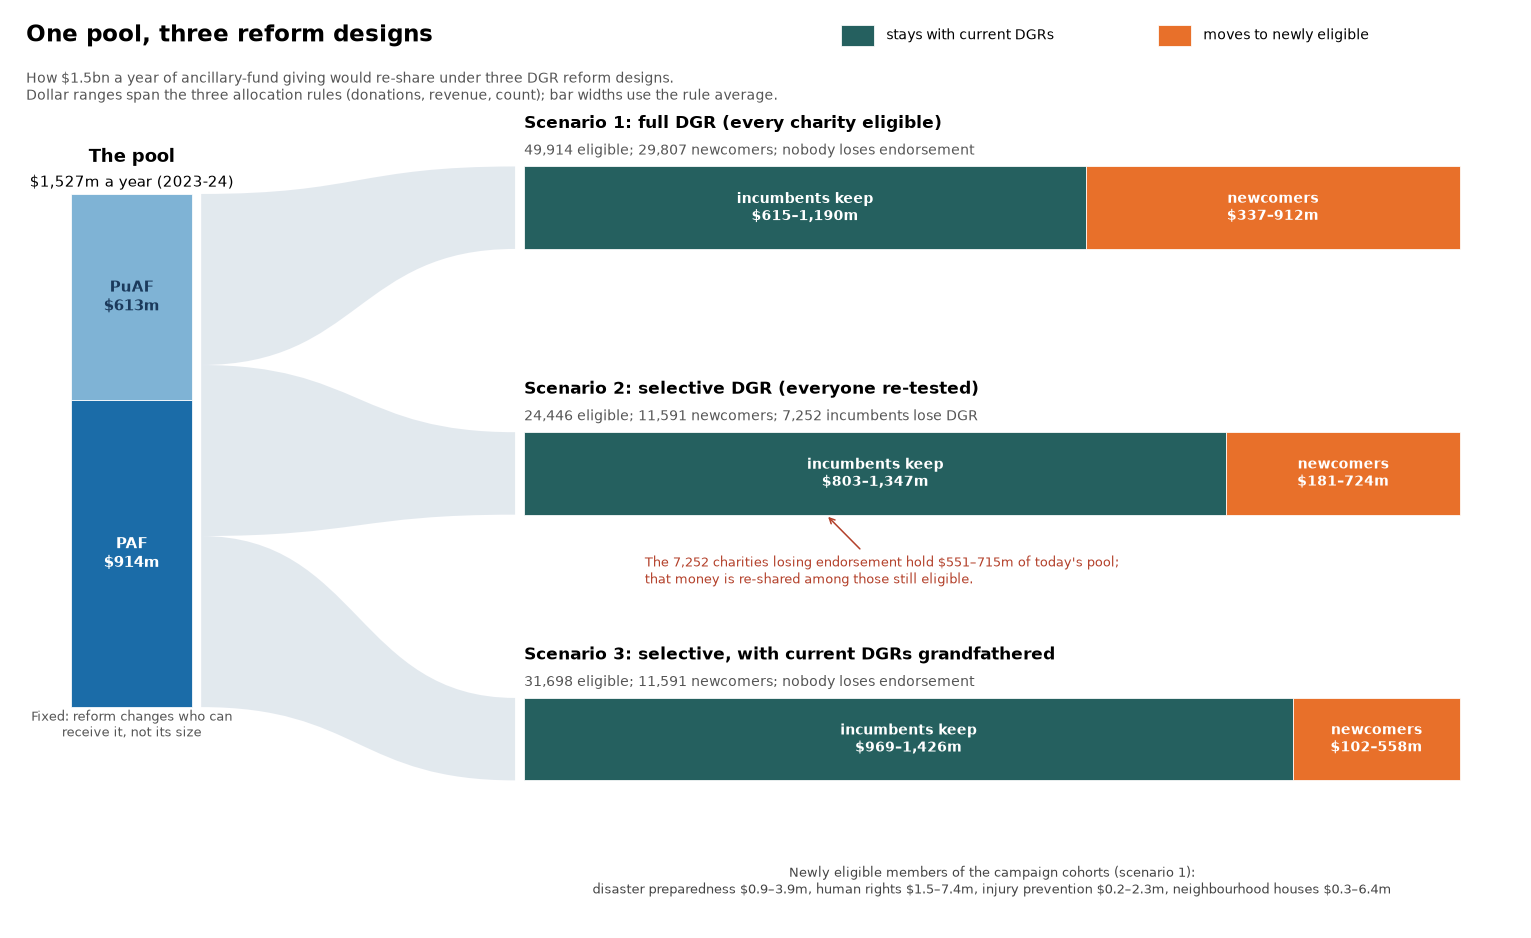

In [49]:
# The poster — one pool, three reform designs
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath

fig, ax = plt.subplots(figsize=(14, 8.5))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis("off")

PM = POOL / 1e6

def ribbon(x0, y0a, y0b, x1, y1a, y1b, color, alpha=0.25):
    """Curved band from edge segment (x0, y0a-y0b) to (x1, y1a-y1b)."""
    cx = (x0 + x1) / 2
    verts = [
        (x0, y0a), (cx, y0a), (cx, y1a), (x1, y1a),
        (x1, y1b), (cx, y1b), (cx, y0b), (x0, y0b), (x0, y0a),
    ]
    codes = [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
             MplPath.LINETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
             MplPath.CLOSEPOLY]
    ax.add_patch(PathPatch(MplPath(verts, codes), fc=color, ec="none", alpha=alpha))

def box(x, y, w, h, color, alpha=1.0):
    p = plt.Rectangle((x, y), w, h, fc=color, ec="white", lw=0.5, alpha=alpha)
    ax.add_patch(p)
    return p

# ---- LEFT: the fixed pool ---------------------------------------------------
px, pw, py, ph = 4, 8, 24, 56
paf_h = ph * 914 / PM
box(px, py, pw, paf_h, C["paf"])
box(px, py + paf_h, pw, ph - paf_h, C["puaf"])
ax.text(px + pw / 2, py + paf_h / 2, "PAF\n\\$914m", ha="center", va="center",
        color="white", fontweight="bold", fontsize=10)
ax.text(px + pw / 2, py + paf_h + (ph - paf_h) / 2, "PuAF\n\\$613m", ha="center",
        va="center", color="#1b3a5c", fontweight="bold", fontsize=10)
ax.text(px + pw / 2, py + ph + 3.5, "The pool", ha="center", fontsize=12, fontweight="bold")
ax.text(px + pw / 2, py + ph + 0.8, "\\$1,527m a year (2023-24)", ha="center", fontsize=10)
ax.text(px + pw / 2, py - 3.2,
        "Fixed: reform changes who can\nreceive it, not its size",
        ha="center", fontsize=8.5, color="#555")

# ---- RIGHT: three scenario bars ----------------------------------------------
bx, bw, bh = 34, 62, 9            # bar geometry
rows = {"full": 74, "selective": 45, "grandfathered": 16}
titles = {
    "full": "Scenario 1: full DGR (every charity eligible)",
    "selective": "Scenario 2: selective DGR (everyone re-tested)",
    "grandfathered": "Scenario 3: selective, with current DGRs grandfathered",
}
subtitles = {
    "full": "49,914 eligible; 29,807 newcomers; nobody loses endorsement",
    "selective": "24,446 eligible; 11,591 newcomers; 7,252 incumbents lose DGR",
    "grandfathered": "31,698 eligible; 11,591 newcomers; nobody loses endorsement",
}

for k, y in rows.items():
    s = S[k]
    sp = s["split"]
    stays_mid = sp["stays"].mean()
    w_stay = bw * stays_mid / PM
    # bar segments
    box(bx, y, w_stay, bh, C["incumbent"])
    box(bx + w_stay, y, bw - w_stay, bh, C["new"])
    # in-bar labels
    ax.text(bx + w_stay / 2, y + bh / 2,
            f"incumbents keep\n\\${sp['stays'].min():,.0f}–{sp['stays'].max():,.0f}m",
            ha="center", va="center", color="white", fontweight="bold", fontsize=9)
    ax.text(bx + w_stay + (bw - w_stay) / 2, y + bh / 2,
            f"newcomers\n\\${sp['moves'].min():,.0f}–{sp['moves'].max():,.0f}m",
            ha="center", va="center", color="white", fontweight="bold", fontsize=9)
    # titles
    ax.text(bx, y + bh + 4.2, titles[k], fontsize=11, fontweight="bold")
    ax.text(bx, y + bh + 1.3, subtitles[k], fontsize=9, color="#555")
    # ribbon from pool to bar
    seg = 56 / 3
    i = list(rows).index(k)
    ribbon(px + pw + 0.6, py + ph - i * seg, py + ph - (i + 1) * seg,
           bx - 0.6, y + bh, y, "#8ea8bf")

# losers note on scenario 2
y2 = rows["selective"]
ax.annotate(
    "The 7,252 charities losing endorsement hold \\$551–715m of today's pool;\n"
    "that money is re-shared among those still eligible.",
    xy=(bx + 20, y2), xytext=(bx + 8, y2 - 7.5),
    fontsize=8.8, color=C["neg"],
    arrowprops=dict(arrowstyle="->", color=C["neg"], lw=1),
)

# footer: campaign cohorts
ax.text(bx + bw / 2, 5,
        "Newly eligible members of the campaign cohorts (scenario 1):\n"
        "disaster preparedness \\$0.9–3.9m, human rights \\$1.5–7.4m, "
        "injury prevention \\$0.2–2.3m, neighbourhood houses \\$0.3–6.4m",
        fontsize=8.5, color="#444", ha="center", va="center")

# legend + title
box(55, 96.2, 2.2, 2.2, C["incumbent"])
ax.text(58, 97.3, "stays with current DGRs", va="center", fontsize=9)
box(76, 96.2, 2.2, 2.2, C["new"])
ax.text(79, 97.3, "moves to newly eligible", va="center", fontsize=9)
ax.text(1, 97.3,
        "One pool, three reform designs", fontsize=15, fontweight="bold", va="center")
ax.text(1, 93.5,
        "How \\$1.5bn a year of ancillary-fund giving would re-share under three DGR reform designs.\n"
        "Dollar ranges span the three allocation rules (donations, revenue, count); bar widths use the rule average.",
        fontsize=9, color="#555", va="top")

fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
plt.show()

## Results

1. **The pool is $1,527m/yr (2023-24)** — $914m from PAFs, $613m from PuAFs — and holds only if giving behaviour continues; net assets are $17.5bn and growing.
2. **Reform moves $337m–$912m of the fixed pool** away from incumbent DGRs, depending on the allocation rule (least under the donations rule, most under the count rule).
3. **Newly-eligible cohort members gain $3.9m–$19.9m/yr combined** across the four campaign cohorts — small relative to the pool because the cohorts are small.
4. **Leakage matters:** three cohorts are ~63–68% already-DGR, so their *whole-cohort* position can worsen under fixed-pool reform (their DGR members get diluted more than the newcomers gain). **neighbourhood_house** (26% DGR) is the only cohort that gains under every rule.
5. **Reality check:** ancillary grants arrive as donations in recipients' AIS, so actual reported donations cap what a cohort can receive. The donations rule always sits at 16.7% of that cap (pool ÷ all DGR donations). The check flags one implausible cell: **neighbourhood_house under the count rule** (modelled \$5.7m vs \$2.5m actually reported — 230% of the ceiling), so treat count-rule figures for small, low-fundraising cohorts as an upper bound on access, not a likely flow.
6. The model is deliberately mechanical. Real granting is relationship-driven and lumpy; these figures bound *access*, not flows. Pie growth (Layer 2, the PC's $1.50-per-$1 multiplier) is the other half of the story and is modelled separately.

**Refinement hook:** when the reform-eligibility flags land (`analysis/reform_eligibility_flags.csv`, one `abn` column), restrict the reform base to current DGRs + flagged charities and re-run — smaller denominators raise every cohort's newly-eligible dollars and reduce incumbent dilution. Unflagged cohort members must then get $0 (Option A, agreed 2026-07-20).